In [6]:
import numpy as np
import pandas as pd
df=pd.read_csv("C:\\Users\\E DHANASRI\\Downloads\\SPSIRDATA.csv")
df.head()

,created_at,entry_id,field1,field2,field3
0,2020-01-01 00:00:00 UTC,1,IR20,1,2000-0-8T45:162:0
1,2020-01-01 08:35:00 UTC,2,IR40,0,2000-0-1T45:162:0
2,2020-01-02 02:12:00 UTC,3,IR22,1,2000-0-4T45:162:0
3,2020-01-02 17:45:00 UTC,4,IR12,0,2000-0-5T45:162:0
4,2020-01-03 05:48:00 UTC,5,IR18,1,2000-0-3T45:162:0


In [7]:
df.tail()

,created_at,entry_id,field1,field2,field3
2764,2023-12-04 23:18:00 UTC,2765,IR39,1,2000-0-4T45:162:0
2765,2023-12-05 16:10:00 UTC,2766,IR27,1,2000-0-4T45:162:0
2766,2023-12-06 00:29:00 UTC,2767,IR24,1,2000-0-1T45:162:0
2767,2023-12-06 15:37:00 UTC,2768,IR22,1,2000-0-8T45:162:0
2768,2023-12-07 06:35:00 UTC,2769,IR48,0,2000-0-2T45:162:0


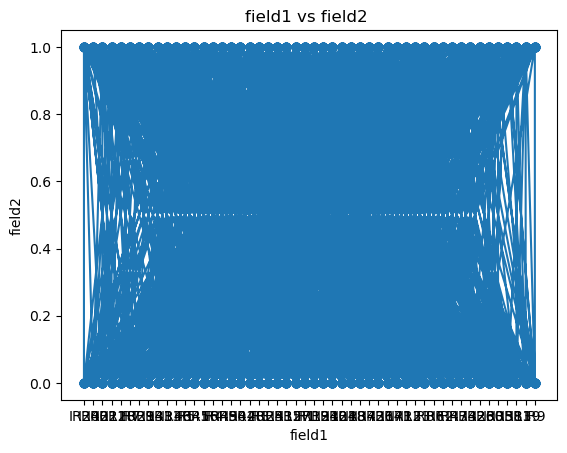

In [5]:
import matplotlib as plt
df=pd.read_csv("C:\\Users\\E DHANASRI\\Downloads\\SPSIRDATA.csv")
field1=df['field1']
field2=df['field2']
plt.plot(field1, field2, marker='o')
plt.title("field1 vs field2 ")
plt.xlabel("field1")
plt.ylabel("field2")
plt.show()

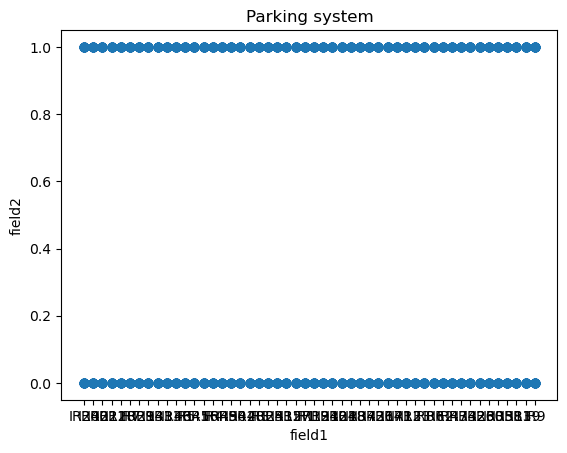

In [8]:
plt.scatter(df['field1'],df['field2'])
plt.title("Parking system")
plt.xlabel("field1")
plt.ylabel("field2")
plt.show()

In [9]:
import heapq
pd.read_csv("C:\\Users\\E DHANASRI\\Downloads\\SPSIRDATA.csv")
graph = {"Entry": {}}
parking_slots = {}
for  index,row in df.iterrows():
    slot = row['field1']
    available = row['field2']
    if slot not in graph:
        graph[slot] = {}
    graph["Entry"][slot] = 1
    graph[slot]["Entry"] = 1
    parking_slots[slot] = True if available == 1 else False
def dijkstra(graph, start):
    pq = []
    heapq.heappush(pq, (0, start))
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}
    while pq:
        current_distance, current_node = heapq.heappop(pq)
        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(pq, (distance, neighbor))
    return distances, previous
def find_nearest_slot(start):
    distances, previous = dijkstra(graph, start)
    nearest_slot = None
    min_distance = float('inf')
    for slot, available in parking_slots.items():
        if available and distances[slot] < min_distance:
            min_distance = distances[slot]
            nearest_slot = slot
    path = []
    current = nearest_slot
    while current:
        path.insert(0, current)
        current = previous[current]
    return nearest_slot, min_distance, path
slot, distance, path = find_nearest_slot("Entry")
print("Nearest Available Slot:", slot)
print("Shortest Distance:", distance)
print("Path:", " -> ".join(path))

Nearest Available Slot: IR20
Shortest Distance: 1
Path: Entry -> IR20
